# 状态图（StateGraph）

在上一节中，我们演示了如何使用 LangGraph 创建 ReAct Agent。但是，把任务交给 Agent 等于把控制权也交了出去。如果你不希望 Agent 拥有如此高的控制权，而是希望流程完全受你控制，那么可以使用 **状态图**（StateGraph）来创建工作流。

> **核心区别**：
> - **ReAct Agent**（`create_agent`）：模型自己决定调不调工具、调什么工具，流程是「黑盒」
> - **StateGraph**：你手动定义节点和边，流程是「白盒」，每一步都受你控制

In [ ]:
import os
from dotenv import load_dotenv          # 读取 .env 文件，加载环境变量
from langchain_openai import ChatOpenAI  # LangChain 封装的 OpenAI 兼容接口（调用 Qwen）

# 这四个是 LangGraph 构建工作流的「积木」（下方表格有更详细解释）：
#   StateGraph     — 图的构建器，用来创建、拼接、编译整个工作流
#   MessagesState  — 状态模板，定义数据结构，内置 'messages' 字段存对话历史
#   START          — 入口标记，工作流起点
#   END            — 出口标记，工作流终点
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.messages import HumanMessage, SystemMessage          # 消息类型：人类消息、系统提示
from langchain.tools import tool         # 将普通 Python 函数装饰成 LangChain 工具
from langgraph.prebuilt import ToolNode  # 预构建的「工具执行节点」
from langchain_core.runnables import RunnableConfig  # 运行时配置对象（传递 thread_id 等）

# 加载 .env 中的环境变量（DASHSCOPE_API_KEY 等）
_ = load_dotenv()

## 整体架构

本节实现了一个简单的工作流。该工作流接入一个查询天气的工具。区别于 ReAct Agent 可以自主实现工具调用，这里我们通过「条件边」，手动编写工具的触发逻辑。

为了实现这一目标，需要先创建三样东西：

- **助手节点（assistant）**：装载了 LLM，用于判断是否需要调用工具。它把用户问题发给模型，模型可能回答文字，也可能返回 tool_call
- **工具节点（tool）**：负责执行工具函数。这里简化为对任何城市均输出「晴天」
- **条件边（conditional edge）**：连接助手节点与工具节点的「分叉路口」。根据助手节点输出的最后一条消息是否包含 tool_calls，决定下一步去哪里

**整个工作流的运行顺序**：
```
用户提问 → START → assistant（模型判断） → [条件判断]
                                    ↓ 需要工具？
                              是 → tool（执行工具） → assistant（基于工具结果回答） → END
                              否 → END（直接结束）
```

In [2]:
# ============================================================
# 1）加载大模型
# ============================================================
llm = ChatOpenAI(
    model="qwen3-coder-plus",
    temperature=0.7,                  # 控制随机性：0.7 有一定创造性
    api_key=os.getenv("DASHSCOPE_API_KEY"),   # 从 .env 读取 API 密钥
    base_url=os.getenv("DASHSCOPE_BASE_URL"), # 从 .env 读取百炼平台 URL
)

# ============================================================
# 2）定义工具函数
# ============================================================
@tool  # 装饰器：让普通 Python 函数变成 LangChain 能识别的工具
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"
    # 这是一个假工具，不查真实天气，直接返回晴天


# ============================================================
# 3）创建工具节点（ToolNode）
# ============================================================
tools = [get_weather]            # 工具列表，传给 ToolNode
tool_node = ToolNode(tools)
# ToolNode 是 LangGraph 预构建的节点，专门负责执行工具
# 它会自动解析 LLM 返回的 tool_call 信息，找到对应的函数并执行


# ============================================================
# 4）创建助手节点（assistant node）
# ============================================================
def assistant(state: MessagesState, config: RunnableConfig):
    """
    助手节点：把当前对话历史发给大模型，让模型决定是「直接回答」还是「调用工具」。
    
    参数：
      - state: 当前 Agent 的状态，包含历史消息（state['messages']）
      - config: 运行时配置（比如 thread_id，用于持久化记忆）
    
    返回值：
      - 一个 dict，包含新产生的消息，会自动合并到 state 中
    """
    # 系统提示：告诉模型它的角色和能力
    system_prompt = 'You are a helpful assistant that can check weather.'
    # 拼接：系统提示 + 用户历史消息 = 完整的上下文
    all_messages = [SystemMessage(system_prompt)] + state['messages']
    
    # 给模型绑定工具描述，让它知道有哪些工具可用
    model = llm.bind_tools(tools)
    
    # 调用大模型，生成回复（可能是纯文字，也可能是 tool_call）
    return {'messages': [model.invoke(all_messages)]}


# ============================================================
# 5）创建条件边（conditional edge）的判断函数
# ============================================================
def should_continue(state: MessagesState, config: RunnableConfig):
    """
    条件边的路由函数：决定下一步走向哪个节点。
    
    核心逻辑：看模型最后一条回复中有没有「工具调用」
      - 有 tool_calls → 返回 'continue'，走工具节点
      - 没有 tool_calls → 返回 'end'，直接结束
    """
    messages = state['messages']   # 取出所有消息
    last_message = messages[-1]    # 只看最后一条（模型刚生成的回复）
    if last_message.tool_calls:    # 如果这条消息里包含工具调用信息
        return 'continue'          # 告诉图：去执行工具
    return 'end'                   # 否则：结束

## 拼接节点和边

有了前面定义的节点和条件判断函数，还需要 **定义它们之间的关系**，即「谁连接谁、按什么顺序执行」。

在 LangGraph 中，这通过 `StateGraph` 的 builder 模式来完成：
1. `add_node()` — 注册节点（给节点取名字，绑定函数）
2. `add_edge()` — 添加固定边（从 A 节点到 B 节点，无条件执行）
3. `add_conditional_edges()` — 添加条件边（从 A 节点出发，根据返回值选分支）
4. `compile()` — 把 builder 编译成可执行的工作流

在下面的代码中，我们先将节点添加到 StateGraph 实例中，然后以正确的顺序桥接它们，最终获得一个可以运行的工作流。

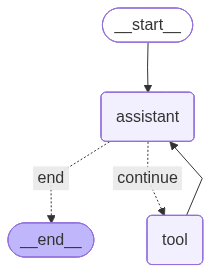

In [3]:
# ============================================================
# 构建状态图（StateGraph）
# ============================================================

# 第一步：创建一个图构建器，基于 MessagesState 作为状态结构
# MessagesState 是 LangGraph 内置的状态类型，里面有一个 'messages' 字段
builder = StateGraph(MessagesState)

# 第二步：往图里注册两个节点
#   'assistant' → 我们的助手函数（调大模型）
#   'tool'      → 工具节点（执行工具函数）
builder.add_node('assistant', assistant)  # 节点名 + 节点函数
builder.add_node('tool', tool_node)       # 节点名 + ToolNode 对象

# 第三步：添加固定的边（无条件，每次都走这条）
#   START → 'assistant' ：工作流从 START 开始，第一步永远是调用助手节点
builder.add_edge(START, 'assistant')

# 第四步：添加条件边（conditional edge）
#   作用：从 'assistant' 节点出来后，根据 should_continue 函数的返回值，决定下一步去哪里
#   返回值是 'continue' → 去 'tool' 节点（执行工具）
#   返回值是 'end'     → 去 END（结束整个工作流）
builder.add_conditional_edges(
    'assistant',        # 条件边从 assistant 节点出发
    should_continue,    # 路由函数：根据状态决定走哪条分支
    {
        'continue': 'tool',  # 如果 should_continue 返回 'continue'，去 tool 节点
        'end': END,          # 如果返回 'end'，结束
    },
)

# 第五步：添加工具执行完之后的回环边
#   'tool' → 'assistant' ：工具跑完后，回到助手节点，让模型基于工具结果生成最终回答
#   这就是「循环」的来源：assistant → tool → assistant → tool → ... 直到模型不再调工具
builder.add_edge('tool', 'assistant')

# 第六步：编译成可执行的图
my_graph = builder.compile(name='my-graph')
my_graph

> **Note — 有向图分为两种**：
>
> - **有向无环图（DAG）**：流程单向走到底，不会回头，适合线性工作流（如：读取 → 处理 → 输出）
> - **有向循环图（DCG）**：允许回头和循环，适合需要迭代的工作流（如：工具调用需要反复来回）

从可视化结果可以看出，`assistant` 与 `tool` 之间存在互相指向的箭头（assistant → tool → assistant），因此这是一个 **有向循环图（DCG）**。

**循环的实际意义**：模型可能需要多次调用工具才能得出最终答案。比如问"上海和北京哪个更热"，可能需要先查上海天气，再查北京天气，再比较。循环让模型可以反复查询直到收集足够信息。

下面来看一下，当询问上海天气时，工作流的实际运行过程。

In [4]:
# ============================================================
# 调用并运行状态图
# ============================================================

# invoke() 是同步阻塞调用：把输入传给图，等整个工作流跑完才返回
# 输入格式：{'messages': [消息列表]}，MessagesState 要求消息必须是 Message 对象
response = my_graph.invoke({
    'messages': [HumanMessage(content='上海天气怎么样？')]
    # 用户问了一句"上海天气怎么样？"
})

# 打印整个对话过程中产生的所有消息（方便调试和查看）
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

上海天气怎么样？
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_1f89ec04c5f24573bf4c56f5)
 Call ID: call_1f89ec04c5f24573bf4c56f5
  Args:
    city: 上海
================================= Tool Message =================================
Name: get_weather

It's always sunny in 上海!
================================== Ai Message ==================================

上海的天气总是晴朗的！不过实际情况可能会有所不同，建议您在出行前查看最新的天气预报以确保做好相应的准备。如果您需要了解其他城市的天气情况，也可以随时告诉我。
